
DATASET:

                          Email_Text Label
0  Congratulations you won a lottery  Spam
1          Claim your free prize now  Spam
2      Limited time offer click here  Spam
3         Win cash rewards instantly  Spam
4        Free vacation available now  Spam
5         Meeting scheduled tomorrow   Ham
6      Please submit your assignment   Ham
7        Project discussion at 10 AM   Ham
8          Let's attend the workshop   Ham
9      Can we reschedule the meeting   Ham

MODEL ACCURACY:

1.0

CLASSIFICATION REPORT:

              precision    recall  f1-score   support

           0       1.00      1.00      1.00         2
           1       1.00      1.00      1.00         1

    accuracy                           1.00         3
   macro avg       1.00      1.00      1.00         3
weighted avg       1.00      1.00      1.00         3


CONFUSION MATRIX:

[[2 0]
 [0 1]]


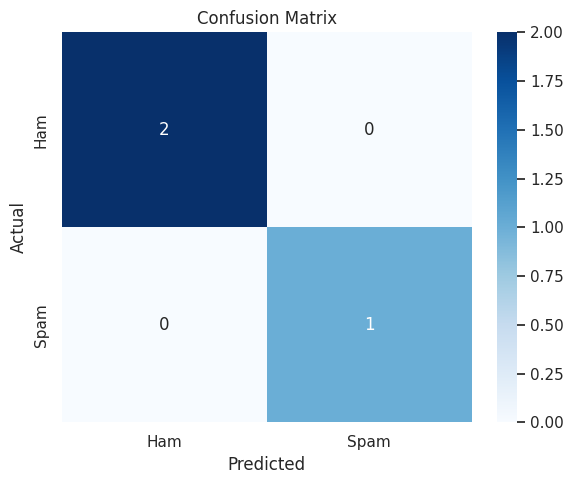


CUSTOM EMAIL PREDICTION:

SPAM EMAIL

PROJECT EXECUTED SUCCESSFULLY!
Confusion Matrix Saved as confusion_matrix.png


In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import accuracy_score
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix

# ============================================================
# CREATE DATASET
# ============================================================

data = {

    "Email_Text": [

        "Congratulations you won a lottery",
        "Claim your free prize now",
        "Limited time offer click here",
        "Win cash rewards instantly",
        "Free vacation available now",

        "Meeting scheduled tomorrow",
        "Please submit your assignment",
        "Project discussion at 10 AM",
        "Let's attend the workshop",
        "Can we reschedule the meeting"

    ],

    "Label": [

        "Spam",
        "Spam",
        "Spam",
        "Spam",
        "Spam",

        "Ham",
        "Ham",
        "Ham",
        "Ham",
        "Ham"

    ]

}

# ============================================================
# CREATE DATAFRAME
# ============================================================

df = pd.DataFrame(data)

print("\nDATASET:\n")
print(df)

# ============================================================
# CONVERT LABELS
# Spam = 1
# Ham = 0
# ============================================================

df["Label"] = df["Label"].map({

    "Ham": 0,
    "Spam": 1

})

# ============================================================
# SPLIT DATA
# ============================================================

X = df["Email_Text"]

y = df["Label"]

X_train, X_test, y_train, y_test = train_test_split(

    X,
    y,
    test_size=0.3,
    random_state=42

)

# ============================================================
# TEXT VECTORIZATION
# ============================================================

vectorizer = CountVectorizer()

X_train_vectorized = vectorizer.fit_transform(X_train)

X_test_vectorized = vectorizer.transform(X_test)

# ============================================================
# TRAIN MACHINE LEARNING MODEL
# ============================================================

model = MultinomialNB()

model.fit(

    X_train_vectorized,
    y_train

)

# ============================================================
# PREDICTIONS
# ============================================================

predictions = model.predict(X_test_vectorized)

# ============================================================
# MODEL EVALUATION
# ============================================================

accuracy = accuracy_score(

    y_test,
    predictions

)

print("\nMODEL ACCURACY:\n")

print(accuracy)

print("\nCLASSIFICATION REPORT:\n")

print(classification_report(

    y_test,
    predictions

))

# ============================================================
# CONFUSION MATRIX
# ============================================================

cm = confusion_matrix(

    y_test,
    predictions

)

print("\nCONFUSION MATRIX:\n")

print(cm)

# ============================================================
# VISUALIZATION
# ============================================================

sns.set(style="darkgrid")

plt.figure(figsize=(6,5))

sns.heatmap(

    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=["Ham", "Spam"],
    yticklabels=["Ham", "Spam"]

)

plt.title("Confusion Matrix")

plt.xlabel("Predicted")

plt.ylabel("Actual")

plt.tight_layout()

# SAVE GRAPH

plt.savefig("confusion_matrix.png")

# SHOW GRAPH

plt.show()

# ============================================================
# TEST CUSTOM EMAIL
# ============================================================

custom_email = [

    "Congratulations! You won free money"

]

custom_email_vectorized = vectorizer.transform(custom_email)

prediction = model.predict(custom_email_vectorized)

print("\nCUSTOM EMAIL PREDICTION:\n")

if prediction[0] == 1:

    print("SPAM EMAIL")

else:

    print("HAM EMAIL")

# ============================================================
# FINAL MESSAGE
# ============================================================

print("\nPROJECT EXECUTED SUCCESSFULLY!")
print("Confusion Matrix Saved as confusion_matrix.png")